<a href="https://colab.research.google.com/github/dngtundt/THDL_DangAnhTuan/blob/main/THDL_Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BUỔI 2 - ANN -
BÀI THỰC HÀNH 3: ARTIFICIAL NEURAL NETWORK

--> Đang tải bộ dữ liệu CIFAR-10 từ thư viện Keras...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Kích thước tập huấn luyện (Train shape): (50000, 32, 32, 3)
Kích thước tập kiểm thử (Test shape): (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


--> Bắt đầu quá trình huấn luyện mạng ANN...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.2778 - loss: 1.9694 - val_accuracy: 0.3442 - val_loss: 1.8246
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3386 - loss: 1.8214 - val_accuracy: 0.3857 - val_loss: 1.7257
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.3546 - loss: 1.7765 - val_accuracy: 0.4035 - val_loss: 1.6973
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3731 - loss: 1.7364 - val_accuracy: 0.4173 - val_loss: 1.6687
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3823 - loss: 1.7062 - val_accuracy: 0.3967 - val_loss: 1.6744
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.3915 - loss: 1.6873 - val_accuracy: 0.4250 - val_loss: 1.6159
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3971 - loss: 1.6641 - val_accuracy: 0.4408 - val_loss: 1.5821
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 

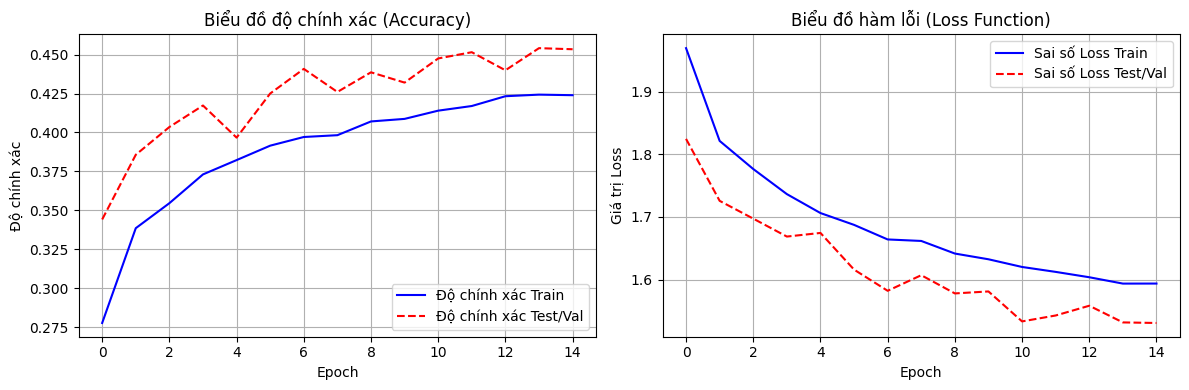

In [ ]:
#Bài tập 1: Xây dựng mạng ANN phân loại 10 lớp ảnh dữ liệu CIFAR-10

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------
# Bước 1: Tải và Tiền xử lý Dữ liệu (Dataset & Features/Labels)
# ----------------------------------------------------------------
print("--> Đang tải bộ dữ liệu CIFAR-10 từ thư viện Keras...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Định nghĩa nhãn chuỗi tường minh cho 10 lớp của CIFAR-10
class_names = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Hươu', 'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']

# Chuẩn hóa giá trị điểm ảnh (Pixel) từ [0, 255] về khoảng số thực [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Kích thước tập huấn luyện (Train shape): {X_train.shape}")
print(f"Kích thước tập kiểm thử (Test shape): {X_test.shape}")

# ----------------------------------------------------------------
# Bước 2: Thiết lập cấu trúc mạng thần kinh (Layers Architecture)
# ----------------------------------------------------------------
# Khởi tạo mô hình mạng tuyến tính tuần tự tuần tự (Sequential)
model = models.Sequential([
    # Tầng chuyển đổi hình học (Flatten): Duỗi ma trận ảnh 3D (32x32x3) thành Vector 1D (3072 phần tử)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Tầng ẩn 1 (Hidden Layer 1): 512 Node neuron, sử dụng hàm kích hoạt ReLU
    layers.Dense(512, activation='relu'),
    # Kỹ thuật Regularization: Dropout ngẫu nhiên ẩn 20% liên kết tránh hiện tượng Overfitting
    layers.Dropout(0.2),

    # Tầng ẩn 2 (Hidden Layer 2): 256 Node neuron, sử dụng hàm kích hoạt ReLU
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    # Tầng ẩn 3 (Hidden Layer 3): 128 Node neuron, sử dụng hàm kích hoạt ReLU
    layers.Dense(128, activation='relu'),

    # Tầng đầu ra (Output Layer): 10 Node tương ứng với xác suất phân bố của 10 lớp phân loại
    # Sử dụng Softmax để chuẩn hóa các giá trị đầu ra thành phân phối xác suất
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc chi tiết và tổng số tham số trọng số (Weights) cần học của mạng
model.summary()

# ----------------------------------------------------------------
# Bước 3: Cấu hình Biên dịch mô hình (Loss function, Optimizer, Metrics)
# ----------------------------------------------------------------
model.compile(
    # Sử dụng bộ tối ưu hóa Adam (Biến thể cải tiến hiệu quả của Stochastic Gradient Descent)
    optimizer='adam',
    # Sử dụng hàm lỗi toán học Sparse Categorical Crossentropy do nhãn y ở dạng số nguyên định danh (Integer Label)
    loss='sparse_categorical_crossentropy',
    # Giám sát độ chính xác tổng thể trong quá trình train
    metrics=['accuracy']
)

# ----------------------------------------------------------------
# Bước 4: Thực hiện Huấn luyện mô hình (Model Fitting)
# ----------------------------------------------------------------
print("\n--> Bắt đầu quá trình huấn luyện mạng ANN...")
# Tiến hành khớp dữ liệu qua 15 chu kỳ (Epochs), mỗi lần lấy cụm (Batch size) gồm 64 mẫu ảnh
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ----------------------------------------------------------------
# Bước 5: Đánh giá hiệu năng và vẽ đồ thị phân tích Overfitting
# ----------------------------------------------------------------
print("\n--> Đang đánh giá độ chính xác của mô hình trên tập Test độc lập...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n[KẾT QUẢ] Độ chính xác trên tập Test (Test Accuracy): {test_acc*100:.2f}%")

# Vẽ biểu đồ liên quan đến độ chính xác (Accuracy) và tổn thất sai số (Loss) qua từng Epoch
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác Train', color='blue')
plt.plot(history.history['val_accuracy'], label='Độ chính xác Test/Val', color='red', linestyle='--')
plt.title('Biểu đồ độ chính xác (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Độ chính xác')
plt.grid(True)
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Sai số Loss Train', color='blue')
plt.plot(history.history['val_loss'], label='Sai số Loss Test/Val', color='red', linestyle='--')
plt.title('Biểu đồ hàm lỗi (Loss Function)')
plt.xlabel('Epoch')
plt.ylabel('Giá trị Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# Bài tập 4: Xây dựng mạng ANN cho dữ liệu bảng (Adult Dataset)
# Dự báo thu nhập >50K hoặc <=50K dựa trên thông tin nhân khẩu học

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Tải dữ liệu trực tiếp từ internet
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

print("--> Đang tải bộ dữ liệu Adult Dataset...")
df = pd.read_csv(url, names=columns, sep=',\s*', engine='python')

# 2. Tiền xử lý dữ liệu chữ (Categorical) và dữ liệu số (Numerical)
# Chuyển đổi nhãn mục tiêu (income) về dạng 0 và 1
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Khai báo các cột dạng chữ cần chuyển đổi số
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Thực hiện One-Hot Encoding cho các cột dạng chữ
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Tách Features (X) và Label (y)
X = df_encoded.drop('income', axis=1).astype(np.float32)
y = df_encoded['income'].values

# Chia tập dữ liệu thành Train và Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu số (Feature Scaling) - Bước cực kỳ quan trọng cho dữ liệu bảng
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Số lượng đặc trưng sau khi xử lý: {X_train.shape[1]}")

# 3. Xây dựng cấu trúc mạng ANN thích hợp cho dữ liệu bảng
# (Không dùng tầng Flatten vì dữ liệu đã là vector 1D sẵn)
model_adult = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    # Tầng đầu ra có 1 node với hàm sigmoid vì đây là phân loại nhị phân (0 hoặc 1)
    layers.Dense(1, activation='sigmoid')
])

# 4. Biên dịch mô hình
model_adult.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Dùng binary_crossentropy cho phân loại nhị phân
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình
print("\n--> Bắt đầu huấn luyện mạng ANN trên Adult Dataset...")
history = model_adult.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# 6. Đánh giá kết quả
test_loss, test_acc = model_adult.evaluate(X_test, y_test, verbose=0)
print(f"\n[KẾT QUẢ] Đô chính xác dự báo thu nhập trên tập Test: {test_acc*100:.2f}%")

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1559/1986207860.py:18: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, names=columns, sep=',\s*', engine='python')


--> Đang tải bộ dữ liệu Adult Dataset...
Số lượng đặc trưng sau khi xử lý: 100

--> Bắt đầu huấn luyện mạng ANN trên Adult Dataset...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8149 - loss: 0.4008 - val_accuracy: 0.8406 - val_loss: 0.3392
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8374 - loss: 0.3510 - val_accuracy: 0.8483 - val_loss: 0.3262
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8449 - loss: 0.3377 - val_accuracy: 0.8528 - val_loss: 0.3227
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8454 - loss: 0.3303 - val_accuracy: 0.8557 - val_loss: 0.3201
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8519 - loss: 0.3229 - val_accuracy: 0.8586 - val_loss: 0.3149
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8523 - loss: 0.3183 - val_accuracy: 0.8598 - val_loss: 0.3145
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.3162 - val_accuracy: 0.8578 - val_loss: 0.3142
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - loss: 0.3124 - val_accuracy: 0.8595 - val_

--> Đang tải bộ dữ liệu cats_vs_dogs từ thư viện TensorFlow...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    30,720,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,761,473 (117.35 MB)

 Trainable params: 30,761,473 (117.35 MB)

 Non-trainable params: 0 (0.00 B)


--> Bắt đầu huấn luyện mạng ANN nhận diện Chó - Mèo...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 232s 391ms/step - accuracy: 0.4948 - loss: 1.4680 - val_accuracy: 0.5103 - val_loss: 0.6930
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 259s 390ms/step - accuracy: 0.4980 - loss: 0.6932 - val_accuracy: 0.5099 - val_loss: 0.6931
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 246s 422ms/step - accuracy: 0.5011 - loss: 0.6929 - val_accuracy: 0.5103 - val_loss: 0.6931
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 236s 402ms/step - accuracy: 0.5011 - loss: 0.6933 - val_accuracy: 0.5099 - val_loss: 0.6930
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 240s 410ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5099 - val_loss: 0.6931
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 240s 409ms/step - accuracy: 0.5010 - loss: 0.6932 - val_accuracy: 0.5099 - val_loss: 0.6931
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 234s 400ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.5099 - val_loss: 0.6931
Epoch 8/10
582/582 ━

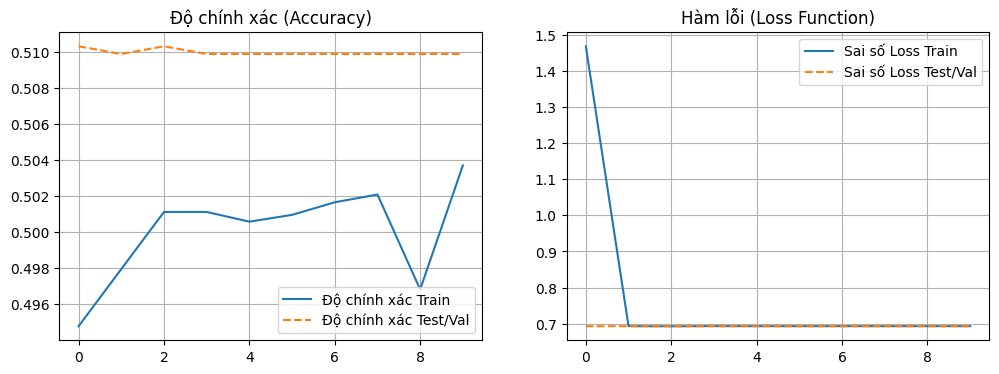

In [ ]:
# ==============================================================================
# BÀI THỰC HÀNH 3: ARTIFICIAL NEURAL NETWORK (ANN)
# Bài tập 3: Tiền xử lý dữ liệu và xây dựng mạng ANN phân loại ảnh Chó vs Mèo
# (Sử dụng tensorflow_datasets để sửa triệt để lỗi BadZipFile)
# ==============================================================================

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# BƯỚC 1: TẢI BỘ DỮ LIỆU TRỰC TIẾP TỪ TENSORFLOW DATASETS
# ------------------------------------------------------------------------------
print("--> Đang tải bộ dữ liệu cats_vs_dogs từ thư viện TensorFlow...")

# Tải dữ liệu và tự động chia tập Train (80%) và Validation (20%)
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,  # Trả về cặp (ảnh, nhãn)
    with_info=True
)

# ------------------------------------------------------------------------------
# BƯỚC 2: TIỀN XỬ LÝ ẢNH (Ép kích thước 200x200 và chuẩn hóa Pixel về [0, 1])
# ------------------------------------------------------------------------------
print("--> Đang thực hiện tiền xử lý và chuẩn hóa kích thước ảnh (200, 200)...")

IMG_SIZE = (200, 200)
BATCH_SIZE = 32

def preprocess_image(image, label):
    # Ép kích thước ảnh về kích thước chuẩn 200x200 như file yêu cầu
    image = tf.image.resize(image, IMG_SIZE)
    # Chuẩn hóa giá trị điểm ảnh (Pixel) về dải [0.0, 1.0]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Áp dụng hàm tiền xử lý lên toàn bộ tập dữ liệu, trộn (shuffle) và đóng gói theo Batch
train_dataset = train_ds.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = val_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# ------------------------------------------------------------------------------
# BƯỚC 3: CẤU TRÚC KIẾN TRÚC MẠNG THẦN KINH ANN HÌNH PHỄU
# ------------------------------------------------------------------------------
model_dog_cat = models.Sequential([
    # Duỗi phẳng ma trận ảnh 3D 200x200x3 thành vector 1D (120,000 chiều)
    layers.Flatten(input_shape=(200, 200, 3)),

    # Tầng ẩn 1
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Tầng ẩn 2
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Tầng ẩn 3
    layers.Dense(64, activation='relu'),

    # Tầng đầu ra: 1 neuron phân loại nhị phân Sigmoid (0: Mèo, 1: Chó)
    layers.Dense(1, activation='sigmoid')
])

model_dog_cat.summary()

# ------------------------------------------------------------------------------
# BƯỚC 4: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# ------------------------------------------------------------------------------
model_dog_cat.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--> Bắt đầu huấn luyện mạng ANN nhận diện Chó - Mèo...")
history = model_dog_cat.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

# ------------------------------------------------------------------------------
# BƯỚC 5: TRỰC QUAN HÓA BIỂU ĐỒ KẾT QUẢ ĐÀO TẠO
# ------------------------------------------------------------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Độ chính xác Train')
plt.plot(epochs_range, val_acc, label='Độ chính xác Test/Val', linestyle='--')
plt.legend(loc='lower right')
plt.title('Độ chính xác (Accuracy)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Sai số Loss Train')
plt.plot(epochs_range, val_loss, label='Sai số Loss Test/Val', linestyle='--')
plt.legend(loc='upper right')
plt.title('Hàm lỗi (Loss Function)')
plt.grid(True)
plt.show()

REGRESSION MODEL

--> Đang tải dữ liệu Boston Housing...
57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

--> Bắt đầu huấn luyện Regression Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[KẾT QUẢ] Sai số tuyệt đối trung bình trên tập Test (Test MAE): 3.12 ($1000)
Nghĩa là mô hình dự báo lệch trung bình khoảng 3118.08 USD so với giá thực tế.


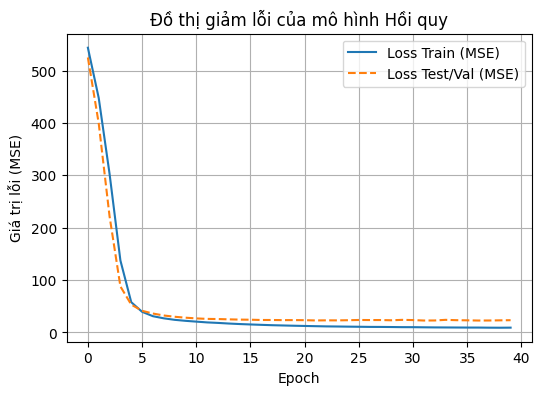

In [ ]:
# ==============================================================================
# BÀI TẬP MỞ RỘNG: XÂY DỰNG MẠNG ANN CHO BÀI TOÁN HỒI QUY (REGRESSION MODEL)
# Dự báo giá nhà dựa trên các đặc trưng kinh tế - xã hội (Boston Housing Dataset)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

# 1. Tải bộ dữ liệu hồi quy Boston Housing có sẵn trong Keras
print("--> Đang tải dữ liệu Boston Housing...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data()

# 2. Chuẩn hóa dữ liệu số (Feature Scaling)
# Vì các cột có đơn vị khác nhau (tỷ lệ tội phạm, số phòng, thuế...) nên cần chuẩn hóa
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# 3. Xây dựng cấu trúc mạng ANN cho bài toán Hồi quy (Regression)
model_regression = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),

    # ĐIỂM KHÁC BIỆT 1: Tầng đầu ra chỉ có 1 node và KHÔNG CÓ hàm kích hoạt (activation)
    layers.Dense(1)
])

# 4. Biên dịch mô hình
model_regression.compile(
    optimizer='adam',
    # ĐIỂM KHÁC BIỆT 2: Hàm loss phải là MSE (Sai số bình phương trung bình)
    loss='mse',
    # ĐIỂM KHÁC BIỆT 3: Thước đo đánh giá là MAE (Sai số tuyệt đối trung bình)
    metrics=['mae']
)

# 5. Huấn luyện mô hình
print("\n--> Bắt đầu huấn luyện Regression Model...")
history = model_regression.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0 # Tắt bớt log hiển thị cho sạch dòng lệnh
)

# 6. Đánh giá mô hình trên tập kiểm thử
test_mse, test_mae = model_regression.evaluate(X_test, y_test, verbose=0)
print(f"\n[KẾT QUẢ] Sai số tuyệt đối trung bình trên tập Test (Test MAE): {test_mae:.2f} ($1000)")
print(f"Nghĩa là mô hình dự báo lệch trung bình khoảng {test_mae * 1000:.2f} USD so với giá thực tế.")

# 7. Vẽ đồ thị lỗi giảm dần qua các Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Loss Train (MSE)')
plt.plot(history.history['val_loss'], label='Loss Test/Val (MSE)', linestyle='--')
plt.title('Đồ thị giảm lỗi của mô hình Hồi quy')
plt.xlabel('Epoch')
plt.ylabel('Giá trị lỗi (MSE)')
plt.grid(True)
plt.legend()
plt.show()